# Persian Sentiment Classification — SnappFood Reviews

This notebook presents a complete, self-contained pipeline for sentiment classification on Persian-language food-delivery reviews, categorizing them into two classes: **Happy** and **Sad**.

Three modeling families are constructed and evaluated end to end:

| Stage | Approach |
|---|---|
| A | Bag-of-words classical ML (Logistic Regression, Random Forest, XGBoost) |
| B | Sequence models in PyTorch (RNN, LSTM, GRU) |
| C | Fine-tuned Persian transformer (ParsBERT) |

Every stage is subjected to an identical evaluation protocol — classification report, confusion matrix, ROC curve, and learning curve — so that the trade-off between "cheap and fast" and "expensive and accurate" is demonstrated empirically rather than assumed a priori.

**Dataset:** SnappFood review corpus, uploaded manually to this Colab session (no external API or Kaggle download required — see the loading cell below).

## Part 1 — Environment

In [6]:
!pip install hazm

In [ ]:
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from hazm import Lemmatizer, Normalizer, Stemmer, WordTokenizer, stopwords_list
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    roc_curve,
)
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.pipeline import Pipeline
from torch.utils.data import DataLoader, Dataset, TensorDataset
from tqdm.auto import tqdm
from wordcloud import WordCloud
from xgboost import XGBClassifier

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_colwidth', None)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 7

## Part 2 — Loading the Raw Data

In [ ]:
DATA_PATH = 'Snappfood - Sentiment Analysis.csv'
raw = pd.read_csv(DATA_PATH, sep='\t', on_bad_lines='skip')
print(f'Loaded {raw.shape[0]} rows, {raw.shape[1]} columns')
raw.head()

Loaded 70000 rows, 4 columns


,Unnamed: 0,comment,label,label_id
0,NaN,واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح,SAD,1.0
1,NaN,قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از موقع رسید، شما ببین چقدرررررررررررر پلاک خفنههههه، من سالهاست مشتریشونم و سالهاست مزه بهشت میده غذاشون,HAPPY,0.0
2,NaN,قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط ظاهر فریبنده داره، پرش میکنن کالباس و قارچ,SAD,1.0
3,NaN,عالللی بود همه چه درست و به اندازه و کیفیت خوب، امیداورم همیشه کیفیتتون خوب باشه ما مشتری همیشگی بشیم,HAPPY,0.0
4,NaN,شیرینی وانیلی فقط یک مدل بود.,HAPPY,0.0


## Part 3 — A Quick First Look

Before doing any cleanup, it's worth checking what we're actually dealing with:
column types, obvious junk columns, and how many labels look inconsistent.

In [9]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  520 non-null    object 
 1   comment     70000 non-null  object 
 2   label       70000 non-null  object 
 3   label_id    69480 non-null  float64
dtypes: float64(1), object(3)
memory usage: 2.1+ MB


In [10]:
raw.filter(like='Unnamed').columns.tolist()

['Unnamed: 0']

In [11]:
raw['label'].value_counts(dropna=False)

,count
label,
HAPPY,34916
SAD,34564
1,436
0,84


## Part 4 — Cleaning Pipeline

Rather than a single monolithic cleaning cell, each fix is applied as its own
small step so it's obvious what each one is responsible for and the row count
can be tracked as we go.

In [ ]:
def drop_index_columns(frame: pd.DataFrame) -> pd.DataFrame:
    junk = [c for c in frame.columns if c.lower().startswith('unnamed')]
    return frame.drop(columns=junk)


def fix_label_consistency(frame: pd.DataFrame) -> pd.DataFrame:
    frame = frame.copy()
    frame['label'] = frame['label'].str.upper().str.strip()
    mismatched_happy = (frame['label'] == 'HAPPY') & (frame['label_id'] != 0)
    mismatched_sad = (frame['label'] == 'SAD') & (frame['label_id'] != 1)
    return frame[~(mismatched_happy | mismatched_sad)]


def keep_persian_only(frame: pd.DataFrame, col: str = 'comment') -> pd.DataFrame:
    has_latin = frame[col].str.contains(r'[a-zA-Z]', na=False)
    return frame[~has_latin]


def trim_length_outliers(frame: pd.DataFrame, col: str = 'comment', quantile: float = 0.95) -> pd.DataFrame:
    frame = frame.copy()
    frame['word_count'] = frame[col].str.split().str.len()
    ceiling = frame['word_count'].quantile(quantile)
    return frame[frame['word_count'] <= ceiling]

Chains all cleaning steps over the raw data: dropping junk columns, removing nulls, fixing label inconsistencies, deduplicating comments, casting types, filtering out non-Persian text, and trimming length outliers. Reports the row count before and after cleaning.

In [ ]:
df = (
    raw
    .pipe(drop_index_columns)
    .dropna()
    .pipe(fix_label_consistency)
    .drop_duplicates(subset=['comment'], keep='first')
    .assign(label_id=lambda d: d['label_id'].astype(int))
    .pipe(keep_persian_only)
    .pipe(trim_length_outliers)
    .reset_index(drop=True)
)

print(f'Rows after cleaning: {len(df)} (started from {len(raw)})')
df.sample(5, random_state=SEED)

Rows after cleaning: 65777 (started from 70000)


,comment,label,label_id,word_count
37702,گوشت برگر کاملا خام بود و وسط گوشت صورتی بود,SAD,1,10
10744,ماهی مونده بود.. دلسترهم ۲تا سفارش داده بودم ۱آورده بودن,SAD,1,10
9129,داغ داغ رسید. طعمش هم نمیتونم بگم عالیه، ولی خوب بود,HAPPY,0,11
6086,وقتی یک عدد دلستر یا نوشابه میخندیم قطعا واسه یخچال نمی‌خوایم واسه خوردن پس خنک باید ارسال بشه نه گرم و آنقدر تکون خورده که نصفش با گاز بیرون بریزه,SAD,1,30
10657,قرار بود ۳۰ دقیقه‌ای بیارن ولی یک ساعت و ۴۰ دقیقه طول کشید و هربار اعلام تاخیر میکردم میگفت تحویل پیک داده شده و ۱۵ دقیقه دیگه میرسه! ۴ بار اعلام تاخیر کردم تا بالاخره اومد. غذاش هم سرد شده بود و از شکل و قیافه هم افتاده بود.,SAD,1,49


## Part 5 — Exploratory Plots

Plots a histogram of comment word-count distribution to visualize how long reviews typically are after cleaning.

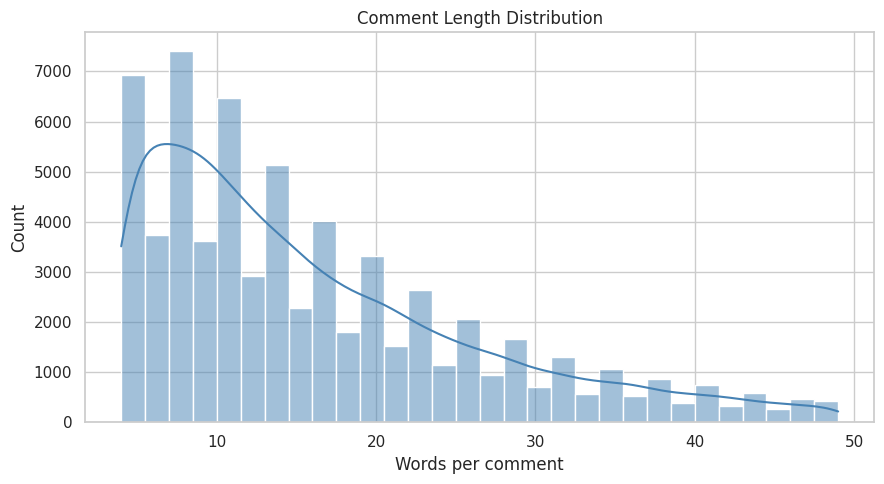

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df['word_count'], bins=30, kde=True, color='steelblue', ax=ax)
ax.set(title='Comment Length Distribution',
       xlabel='Words per comment', ylabel='Count')
plt.tight_layout()
plt.show()

Shows a bar chart of class balance (Happy vs Sad) to check whether the dataset is balanced or needs special attention during model evaluation.

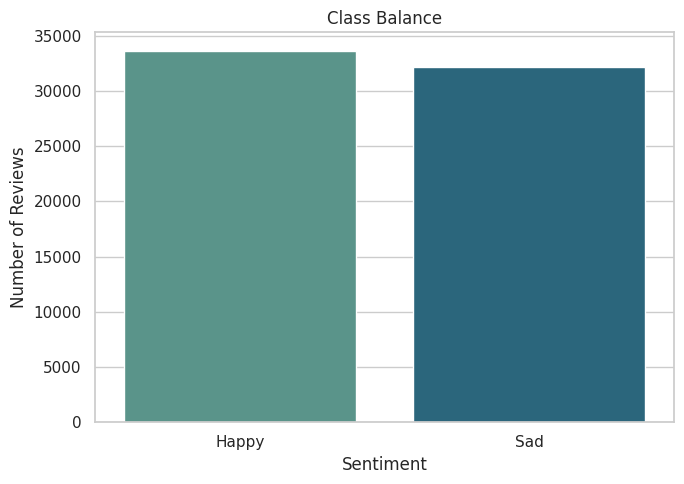

In [ ]:
counts = df['label_id'].value_counts().sort_index()
class_names = {0: 'Happy', 1: 'Sad'}

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=[class_names[i] for i in counts.index],
            y=counts.values, palette='crest', ax=ax)
ax.set(title='Class Balance', xlabel='Sentiment', ylabel='Number of Reviews')
plt.tight_layout()
plt.show()

A violin plot compares comment length across sentiment classes to check whether review length correlates with sentiment.

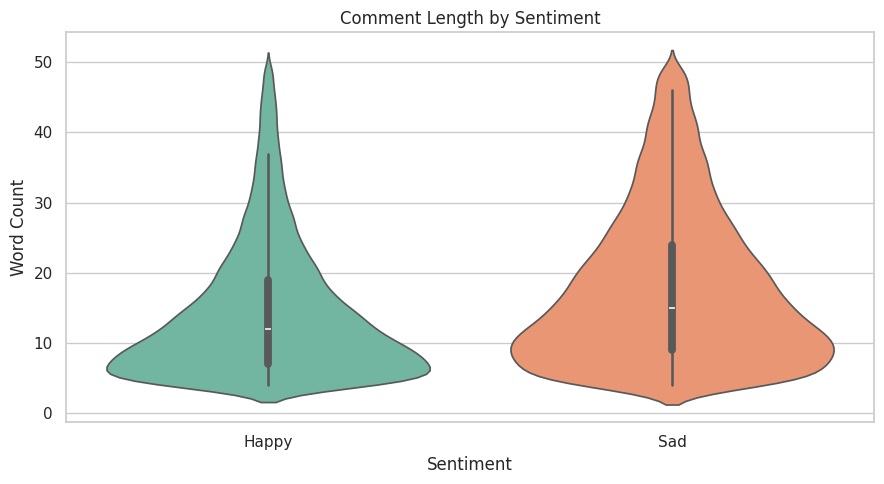

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(x='label_id', y='word_count', data=df, palette='Set2', ax=ax)
ax.set(title='Comment Length by Sentiment',
       xlabel='Sentiment', ylabel='Word Count')
ax.set_xticklabels(['Happy', 'Sad'])
plt.tight_layout()
plt.show()

### Word clouds per sentiment

A quick qualitative pass at what people actually write, split by class. Persian

In [17]:
!pip install arabic-reshaper python-bidi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 10.6 MB/s eta 0:00:00


Downloads the "Vazirmatn" Persian font so Persian text renders correctly and legibly in the word cloud.

In [18]:
!wget -q https://github.com/rastikerdar/vazirmatn/raw/master/fonts/ttf/Vazirmatn-Regular.ttf -O /content/Vazirmatn-Regular.ttf

Normalizes, tokenizes, and stopword-filters each comment's text, then reshapes it for correct WordCloud rendering. Finally draws a separate word cloud per class (Happy/Sad) to visually compare each group's most frequent vocabulary.

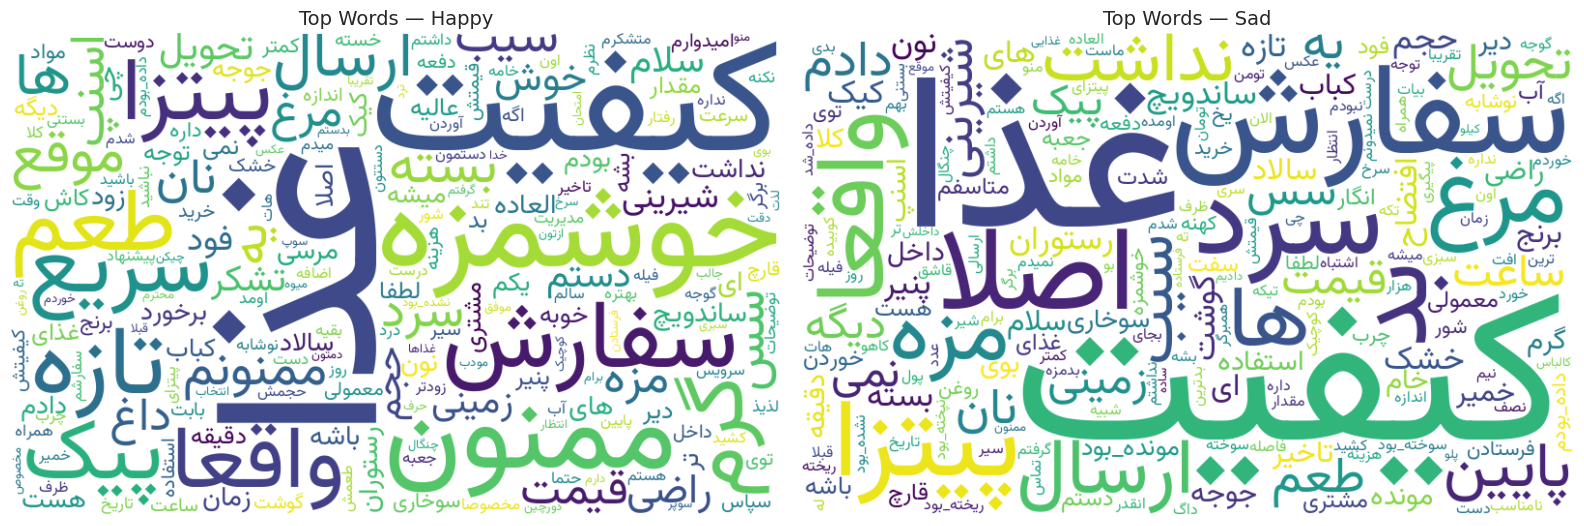

In [ ]:
import re
import arabic_reshaper
from bidi.algorithm import get_display
from wordcloud import WordCloud
import matplotlib.pyplot as plt

FONT_PATH = '/content/Vazirmatn-Regular.ttf'
_persian_stopwords = set(stopwords_list())
_normalizer = Normalizer()
_tokenizer = WordTokenizer()


def prepare_for_wordcloud(word: str) -> str:
    return arabic_reshaper.reshape(word)


def strip_for_cloud(text: str) -> str:
    text = _normalizer.normalize(str(text))
    text = re.sub(r'[^\s\u0600-\u06FF]', ' ', text)
    tokens = _tokenizer.tokenize(text)
    cleaned_tokens = [
        t for t in tokens if t not in _persian_stopwords and len(t) > 1]
    reshaped_tokens = [prepare_for_wordcloud(t) for t in cleaned_tokens]
    return ' '.join(reshaped_tokens)


df['comment_for_cloud'] = df['comment'].apply(strip_for_cloud)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (label_id, name) in zip(axes, class_names.items()):
    joined = ' '.join(df.loc[df['label_id'] == label_id, 'comment_for_cloud'])

    if not joined.strip():
        ax.set_title(f'No words for — {name}')
        ax.axis('off')
        continue

    cloud = WordCloud(
        font_path=FONT_PATH,
        background_color='white',
        width=800,
        height=500,
        collocations=False
    ).generate(joined)

    title_text = get_display(arabic_reshaper.reshape(f'Top Words — {name}'))

    ax.imshow(cloud, interpolation='bilinear')
    ax.set_title(title_text, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Part 6 — Text Preprocessing Utility

One configurable class handles normalization, tokenization, stopword removal,
and either stemming or lemmatization — the mode is chosen per model family
further down (stemming for bag-of-words models, lemmatization for the
sequence/transformer models, which benefit from more word-like tokens).

In [ ]:
class PersianNormalizer:
    def __init__(self, reduction: str = 'stem'):
        assert reduction in {'stem', 'lemma', None}
        self.reduction = reduction
        self.normalizer = Normalizer()
        self.tokenizer = WordTokenizer()
        self.stemmer = Stemmer()
        self.lemmatizer = Lemmatizer()
        self.stopwords = set(stopwords_list())

    def __call__(self, text: str) -> str:
        cleaned = re.sub(r'[^\w\s\u0600-\u06FF]', '', str(text))
        cleaned = self.normalizer.normalize(cleaned)
        tokens = [t for t in self.tokenizer.tokenize(
            cleaned) if t not in self.stopwords]

        if self.reduction == 'stem':
            tokens = [self.stemmer.stem(t) for t in tokens]
        elif self.reduction == 'lemma':
            tokens = [self.lemmatizer.lemmatize(t) for t in tokens]

        return ' '.join(tokens)

In [ ]:
features, target = df['comment'], df['label_id']
features.shape, target.shape

((65777,), (65777,))

## Part 7 — Reusable Evaluation Helpers


In [ ]:
def show_confusion(y_true, y_pred, title, ax=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Happy', 'Sad'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    (ax or plt.gca()).set_title(title)


def compare_metrics(reports: dict, title: str, rotation: int = 0):
    rows = {}
    for name, report in reports.items():
        rows.setdefault('accuracy', []).append(report['accuracy'])
        for metric in ('precision', 'recall', 'f1-score'):
            rows.setdefault(metric, []).append(report['macro avg'][metric])

    frame = pd.DataFrame(rows, index=reports.keys())
    frame.plot(kind='bar', figsize=(11, 5.5))
    plt.title(title)
    plt.ylabel('Score')
    plt.xticks(rotation=rotation)
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.show()
    return frame


def overlay_roc(scores: dict, y_true, title: str = 'ROC Curve Comparison'):
    plt.figure(figsize=(7.5, 6.5))
    for name, y_score in scores.items():
        fpr, tpr, _ = roc_curve(y_true, y_score)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')
    plt.plot([0, 1], [0, 1], '--', color='gray', label='Chance')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def sklearn_learning_curve(estimator, X, y, title: str, cv: int = 5, scoring: str = 'f1_macro'):
    sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1,
    )
    plt.figure(figsize=(7.5, 6))
    plt.plot(sizes, train_scores.mean(axis=1), 'o-', label='Train')
    plt.plot(sizes, val_scores.mean(axis=1), 'o-', label='Cross-val')
    plt.fill_between(sizes, train_scores.mean(1) - train_scores.std(1),
                     train_scores.mean(1) + train_scores.std(1), alpha=0.15)
    plt.fill_between(sizes, val_scores.mean(1) - val_scores.std(1),
                     val_scores.mean(1) + val_scores.std(1), alpha=0.15)
    plt.title(f'Learning Curve — {title}')
    plt.xlabel('Training examples')
    plt.ylabel(scoring)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def loss_curve(history: dict, title: str):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(7.5, 6))
    plt.plot(epochs, history['train_loss'], 'o-', label='Train loss')
    plt.plot(epochs, history['val_loss'], 'o-', label='Val loss')
    plt.title(f'Learning Curve — {title}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Part 8 — Stage A: Bag-of-Words Classical ML

Each classifier is wrapped as a single scikit-learn 
`Pipeline`         
(`clean → TF-IDF → classifier`), so preprocessing, vectorization, and
prediction always travel together instead of being applied as separate,
easy-to-desync steps.

In [ ]:
class PersianCleanerStep(BaseEstimator, TransformerMixin):

    def __init__(self, reduction='stem'):
        self.reduction = reduction

    def fit(self, X, y=None):
        self._normalizer = PersianNormalizer(reduction=self.reduction)
        return self

    def transform(self, X):
        return X.apply(self._normalizer)


def make_pipeline(estimator) -> Pipeline:
    return Pipeline([
        ('clean', PersianCleanerStep(reduction='stem')),
        ('tfidf', TfidfVectorizer(max_features=6000)),
        ('model', estimator),
    ])

Splits the data into train/test sets and trains three classical models (Logistic Regression, Random Forest, XGBoost), each inside a full Pipeline. Stores each model's classification report and ROC scores for comparison in later cells.

In [ ]:
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    features, target, test_size=0.2, random_state=SEED, stratify=target
)

candidate_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=SEED),
}

fitted_pipelines, ml_reports, ml_roc_scores = {}, {}, {}

for name, estimator in candidate_models.items():
    pipe = make_pipeline(estimator)
    pipe.fit(Xa_train, ya_train)
    preds = pipe.predict(Xa_test)

    print(f'--- {name} ---')
    print(classification_report(ya_test, preds))

    fitted_pipelines[name] = pipe
    ml_reports[name] = classification_report(ya_test, preds, output_dict=True)
    ml_roc_scores[name] = pipe.predict_proba(Xa_test)[:, 1]

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.84      0.80      0.82      6726
           1       0.80      0.84      0.82      6430

    accuracy                           0.82     13156
   macro avg       0.82      0.82      0.82     13156
weighted avg       0.82      0.82      0.82     13156

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.85      0.77      0.81      6726
           1       0.78      0.86      0.82      6430

    accuracy                           0.81     13156
   macro avg       0.82      0.81      0.81     13156
weighted avg       0.82      0.81      0.81     13156

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      6726
           1       0.80      0.83      0.81      6430

    accuracy                           0.81     13156
   macro avg       0.81      0.81      0.81     13156
weighted

Compares the three classical models' metrics in a single bar chart.

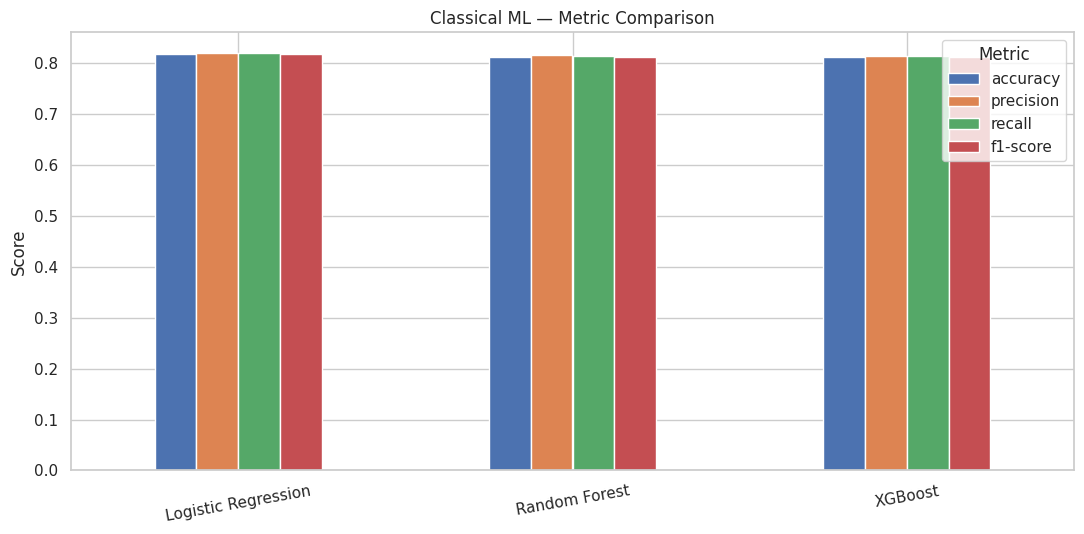

In [ ]:
_ = compare_metrics(
    ml_reports, title='Classical ML — Metric Comparison', rotation=10)

Plots the confusion matrix for each of the three classical models side by side to visually compare error patterns.

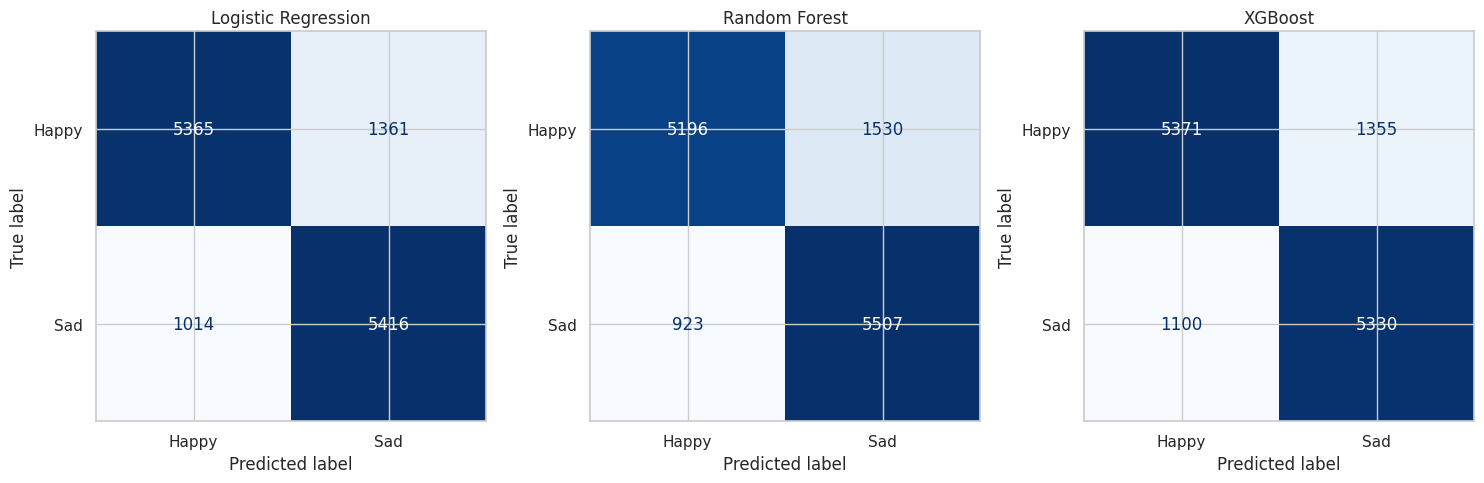

In [ ]:
fig, axes = plt.subplots(1, len(fitted_pipelines), figsize=(15, 5))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    show_confusion(ya_test, pipe.predict(Xa_test), name, ax=ax)
plt.tight_layout()
plt.show()

Overlays the ROC curves of all three classical models on a single chart to compare their discriminative power.

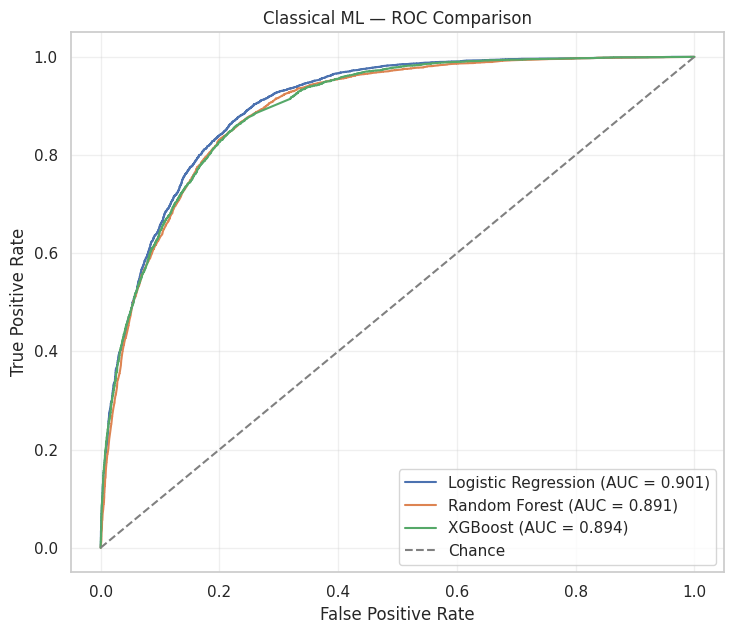

In [28]:
overlay_roc(ml_roc_scores, ya_test, title='Classical ML — ROC Comparison')

Plots a learning curve for each classical model to reveal overfitting/underfitting behavior and how much more data would help.

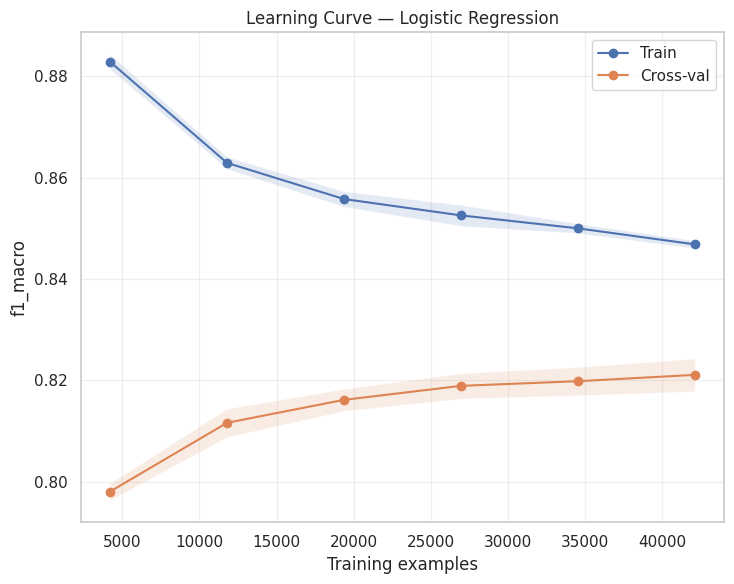

KeyboardInterrupt: 

In [ ]:
for name, pipe in fitted_pipelines.items():
    sklearn_learning_curve(pipe, Xa_train, ya_train, title=name)

## Part 9 — Stage B: Sequence Models (RNN / LSTM / GRU)

Rather than three near-identical classes, one `SequenceClassifier` accepts the
recurrent cell type (`nn.RNN`, `nn.LSTM`, or `nn.GRU`) as a constructor
argument, keeping the architecture definition in one place.

In [ ]:
def build_vocab(token_lists, vocab_size=10000, oov='<OOV>'):
    counts = Counter(tok for text in token_lists for tok in text.split())
    top = counts.most_common(vocab_size - 2)
    vocab = {word: i + 2 for i, (word, _) in enumerate(top)}
    vocab['<PAD>'] = 0
    vocab[oov] = 1
    return vocab


def encode(token_lists, vocab, oov='<OOV>'):
    return [[vocab.get(tok, vocab[oov]) for tok in text.split()] for text in token_lists]


def pad(sequences, length):
    out = []
    for seq in sequences:
        seq = seq[:length] if len(
            seq) >= length else seq + [0] * (length - len(seq))
        out.append(torch.tensor(seq, dtype=torch.long))
    return torch.stack(out)


class ReviewDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = torch.tensor(labels.values, dtype=torch.float32)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

Splits the data into train/validation/test (70/15/15), lemmatizes the text, builds the vocabulary, and converts padded integer sequences into PyTorch `DataLoader`s ready for training the sequence models.

In [ ]:
Xb_train, Xb_temp, yb_train, yb_temp = train_test_split(
    features, target, test_size=0.3, random_state=SEED, stratify=target
)
Xb_val, Xb_test, yb_val, yb_test = train_test_split(
    Xb_temp, yb_temp, test_size=0.5, random_state=SEED, stratify=yb_temp
)

lemmatize = PersianNormalizer(reduction='lemma')
Xb_train_tok = Xb_train.apply(lemmatize)
Xb_val_tok = Xb_val.apply(lemmatize)
Xb_test_tok = Xb_test.apply(lemmatize)

vocab = build_vocab(Xb_train_tok, vocab_size=10000)
seq_len = int(np.max([len(s.split()) for s in Xb_train_tok]))
print(f'vocab size = {len(vocab)}, sequence length = {seq_len}')

train_ds = ReviewDataset(pad(encode(Xb_train_tok, vocab), seq_len), yb_train)
val_ds = ReviewDataset(pad(encode(Xb_val_tok, vocab), seq_len), yb_val)
test_ds = ReviewDataset(pad(encode(Xb_test_tok, vocab), seq_len), yb_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128)
test_loader = DataLoader(test_ds, batch_size=128)

vocab size = 10000, sequence length = 41


Defines a single generic network architecture that accepts the recurrent cell type (`nn.RNN`, `nn.LSTM`, or `nn.GRU`) as a parameter, avoiding three nearly-identical classes. It includes an embedding layer, a 2-layer bidirectional recurrent layer, and a small classification head.

In [ ]:
class SequenceClassifier(nn.Module):
    def __init__(self, cell_type, vocab_size, embed_dim=128, hidden_dim=128, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx)
        self.recurrent = cell_type(
            embed_dim, hidden_dim, num_layers=2, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        embedded = self.embedding(x)
        raw_output = self.recurrent(embedded)
        hidden = raw_output[1][0] if isinstance(
            raw_output[1], tuple) else raw_output[1]
        combined = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.head(combined).squeeze(1)

In [ ]:
def run_training(model, train_loader, val_loader, epochs=30, patience=8):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCELoss()

    best_val, stale_epochs, best_state = float('inf'), 0, None
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x_batch), y_batch)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss = running_loss / len(train_loader)

        model.eval()
        with torch.no_grad():
            val_loss = np.mean([
                criterion(model(x.to(DEVICE)), y.to(DEVICE)).item()
                for x, y in val_loader
            ])

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(
            f'epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}')

        if val_loss < best_val:
            best_val, best_state, stale_epochs = val_loss, model.state_dict(), 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                print('stopping early')
                break

    model.load_state_dict(best_state)
    return model, history


def run_inference(model, loader):
    model.to(DEVICE).eval()
    scores, labels = [], []
    with torch.no_grad():
        for x_batch, y_batch in loader:
            probs = model(x_batch.to(DEVICE)).cpu().numpy()
            scores.extend(probs)
            labels.extend(y_batch.numpy())
    preds = [int(p > 0.5) for p in scores]
    return np.array(scores), np.array(labels), preds

In [ ]:
cell_types = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}
seq_reports, seq_histories, seq_roc_scores, seq_labels = {}, {}, {}, None

for name, cell in cell_types.items():
    print(f'=== training {name} ===')
    net = SequenceClassifier(
        cell, vocab_size=len(vocab), pad_idx=vocab['<PAD>'])
    net, history = run_training(net, train_loader, val_loader)
    scores, labels, preds = run_inference(net, test_loader)

    print(classification_report(labels, preds))
    seq_reports[name] = classification_report(labels, preds, output_dict=True)
    seq_histories[name] = history
    seq_roc_scores[name] = scores
    seq_labels = labels

=== training RNN ===
epoch 01 | train 0.5123 | val 0.4602
epoch 02 | train 0.4454 | val 0.4321
epoch 03 | train 0.3993 | val 0.4104
epoch 04 | train 0.3790 | val 0.4178
epoch 05 | train 0.3527 | val 0.4316
epoch 06 | train 0.3347 | val 0.4285
epoch 07 | train 0.3171 | val 0.4334
epoch 08 | train 0.2957 | val 0.4261
epoch 09 | train 0.2779 | val 0.4434
epoch 10 | train 0.2540 | val 0.4889
epoch 11 | train 0.2429 | val 0.4615
stopping early
              precision    recall  f1-score   support

         0.0       0.83      0.78      0.81      5045
         1.0       0.79      0.83      0.81      4822

    accuracy                           0.81      9867
   macro avg       0.81      0.81      0.81      9867
weighted avg       0.81      0.81      0.81      9867

=== training LSTM ===
epoch 01 | train 0.4614 | val 0.4000
epoch 02 | train 0.3836 | val 0.3907
epoch 03 | train 0.3496 | val 0.3924
epoch 04 | train 0.3121 | val 0.4079
epoch 05 | train 0.2685 | val 0.4773
epoch 06 | train 0.2235

Compares the metrics of the three sequence models (RNN, LSTM, GRU) in a single chart.

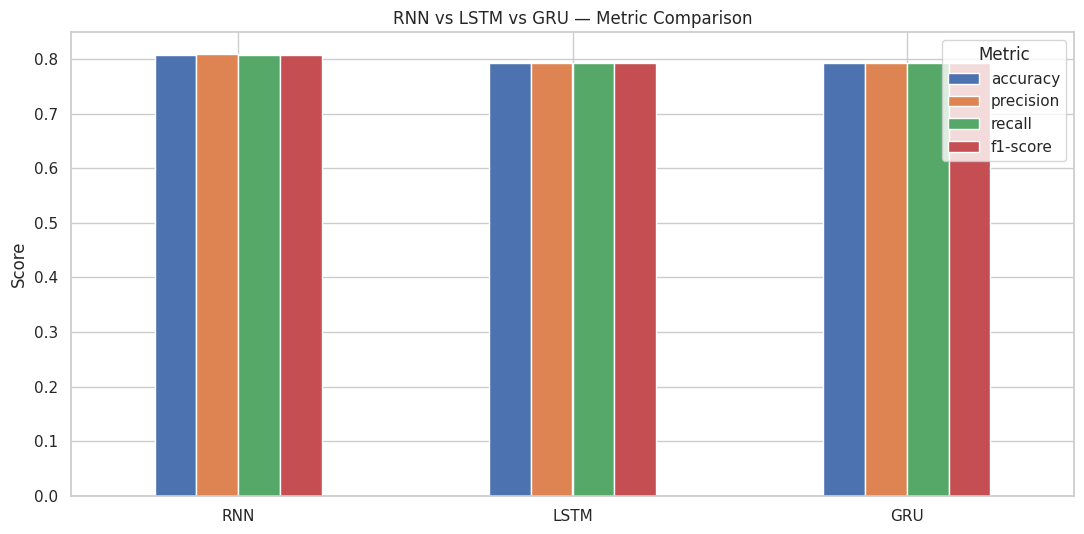

In [ ]:
_ = compare_metrics(
    seq_reports, title='RNN vs LSTM vs GRU — Metric Comparison')

Overlays the ROC curves of the three sequence models on a single chart.

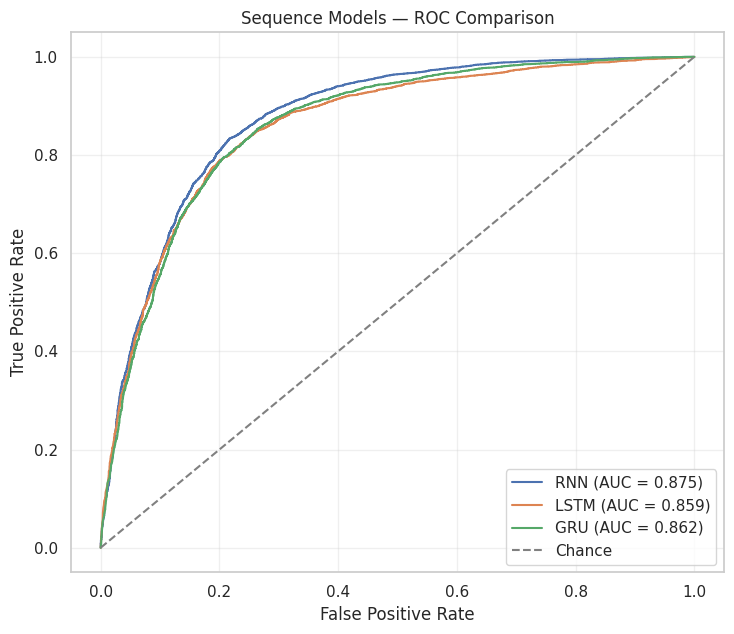

In [ ]:
overlay_roc(seq_roc_scores, seq_labels,
            title='Sequence Models — ROC Comparison')

Plots the training/validation loss curve for each sequence model.

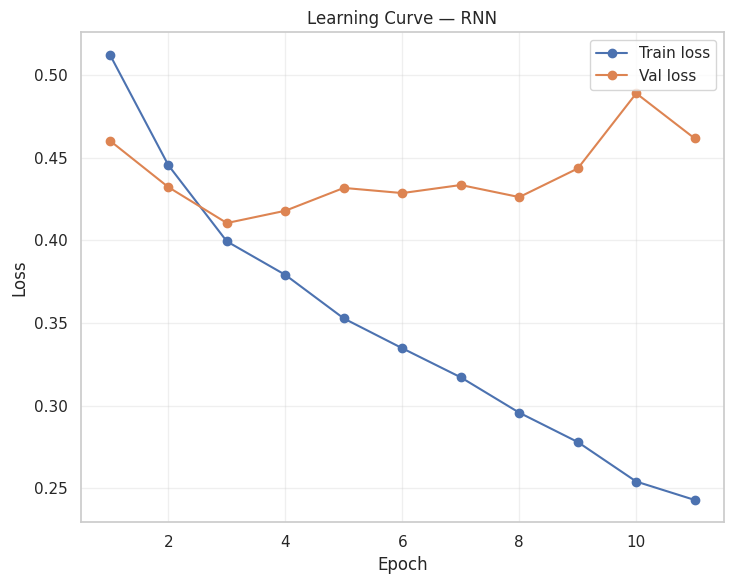

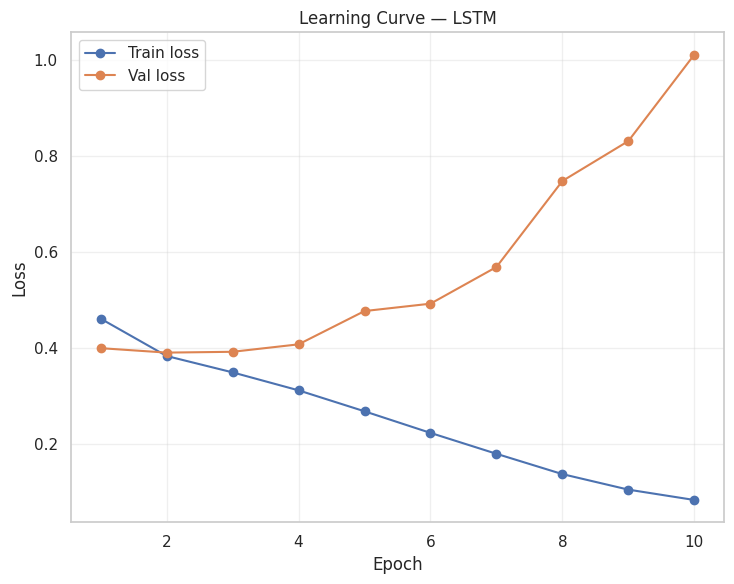

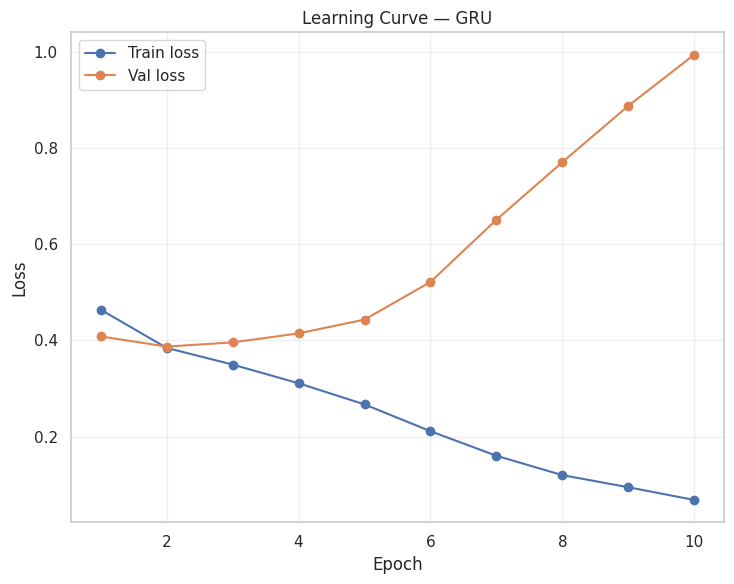

In [ ]:
for name, history in seq_histories.items():
    loss_curve(history, title=name)

## Part 10 — Stage C: Fine-Tuning ParsBERT

The final stage fine-tunes `HooshvareLab/bert-fa-base-uncased` — a BERT model
pretrained on Persian — for this binary classification task, using a
70/15/15 train/val/test split, early stopping on validation loss, and a
plateau-based LR scheduler.

In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
Xc_train, Xc_temp, yc_train, yc_temp = train_test_split(
    features, target, test_size=0.3, random_state=SEED, stratify=target
)
Xc_val, Xc_test, yc_val, yc_test = train_test_split(
    Xc_temp, yc_temp, test_size=0.5, random_state=SEED, stratify=yc_temp
)

light_clean = PersianNormalizer(reduction=None)
Xc_train_tok = Xc_train.apply(light_clean)
Xc_val_tok = Xc_val.apply(light_clean)
Xc_test_tok = Xc_test.apply(light_clean)

CHECKPOINT = 'HooshvareLab/bert-fa-base-uncased'
bert_tok = AutoTokenizer.from_pretrained(CHECKPOINT)
bert_net = AutoModelForSequenceClassification.from_pretrained(
    CHECKPOINT, num_labels=2).to(DEVICE)


def encode_for_bert(texts, max_len=64):
    return bert_tok(texts.tolist(), padding='max_length', truncation=True,
                    max_length=max_len, return_tensors='pt')


enc_train = encode_for_bert(Xc_train_tok)
enc_val = encode_for_bert(Xc_val_tok)
enc_test = encode_for_bert(Xc_test_tok)

bert_train_loader = DataLoader(
    TensorDataset(enc_train['input_ids'], enc_train['attention_mask'],
                  torch.tensor(yc_train.values, dtype=torch.long)),
    batch_size=32, shuffle=True,
)
bert_val_loader = DataLoader(
    TensorDataset(enc_val['input_ids'], enc_val['attention_mask'],
                  torch.tensor(yc_val.values, dtype=torch.long)),
    batch_size=32,
)
bert_test_loader = DataLoader(
    TensorDataset(enc_test['input_ids'], enc_test['attention_mask'],
                  torch.tensor(yc_test.values, dtype=torch.long)),
    batch_size=32,
)

config.json:   0%|          | 0.00/440 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.20M [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  654MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: HooshvareLab/bert-fa-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

model.safetensors: reconstructing file:   0%|          |  0.00B /  654MB            

model.safetensors: downloading bytes:           |  0.00B            

Runs the ParsBERT fine-tuning loop: each epoch updates the model on training data and evaluates on validation data, saves the best weights, reduces the learning rate on plateau, and applies early stopping.

In [ ]:
optimizer = torch.optim.AdamW(bert_net.parameters(), lr=1e-5)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=1)

max_epochs, patience, stale = 10, 3, 0
best_val_loss, best_state = float('inf'), None
bert_history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, max_epochs + 1):
    bert_net.train()
    running = 0.0
    for input_ids, mask, labels in tqdm(bert_train_loader, desc=f'epoch {epoch} train', leave=False):
        input_ids, mask, labels = input_ids.to(
            DEVICE), mask.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out = bert_net(input_ids, attention_mask=mask, labels=labels)
        out.loss.backward()
        optimizer.step()
        running += out.loss.item()
    train_loss = running / len(bert_train_loader)

    bert_net.eval()
    running = 0.0
    with torch.no_grad():
        for input_ids, mask, labels in bert_val_loader:
            input_ids, mask, labels = input_ids.to(
                DEVICE), mask.to(DEVICE), labels.to(DEVICE)
            out = bert_net(input_ids, attention_mask=mask, labels=labels)
            running += out.loss.item()
    val_loss = running / len(bert_val_loader)

    bert_history['train_loss'].append(train_loss)
    bert_history['val_loss'].append(val_loss)
    print(f'epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss, best_state, stale = val_loss, bert_net.state_dict(), 0
        print('  ↳ new best, checkpoint saved')
    else:
        stale += 1
        print(f'  ↳ no improvement ({stale}/{patience})')
        if stale >= patience:
            print('early stopping')
            break

    scheduler.step(val_loss)

epoch 1 train:   0%|          | 0/1439 [00:00<?, ?it/s]

epoch 01 | train 0.4065 | val 0.3716
  ↳ new best, checkpoint saved


epoch 2 train:   0%|          | 0/1439 [00:00<?, ?it/s]

epoch 02 | train 0.3374 | val 0.3796
  ↳ no improvement (1/3)


epoch 3 train:   0%|          | 0/1439 [00:00<?, ?it/s]

epoch 03 | train 0.2873 | val 0.3956
  ↳ no improvement (2/3)


epoch 4 train:   0%|          | 0/1439 [00:00<?, ?it/s]

epoch 04 | train 0.2100 | val 0.4308
  ↳ no improvement (3/3)
early stopping


In [ ]:
if best_state is not None:
    bert_net.load_state_dict(best_state)

bert_net.eval()
bert_scores, bert_labels, bert_preds = [], [], []
with torch.no_grad():
    for input_ids, mask, labels in tqdm(bert_test_loader, desc='test set'):
        input_ids, mask = input_ids.to(DEVICE), mask.to(DEVICE)
        probs = torch.softmax(
            bert_net(input_ids, attention_mask=mask).logits, dim=1)
        bert_scores.extend(probs[:, 1].cpu().numpy())
        bert_preds.extend(probs.argmax(dim=1).cpu().numpy())
        bert_labels.extend(labels.numpy())

print(classification_report(bert_labels, bert_preds))

test set:   0%|          | 0/309 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      5045
           1       0.80      0.87      0.84      4822

    accuracy                           0.83      9867
   macro avg       0.84      0.83      0.83      9867
weighted avg       0.84      0.83      0.83      9867



Plots ParsBERT's confusion matrix and its metric summary chart.

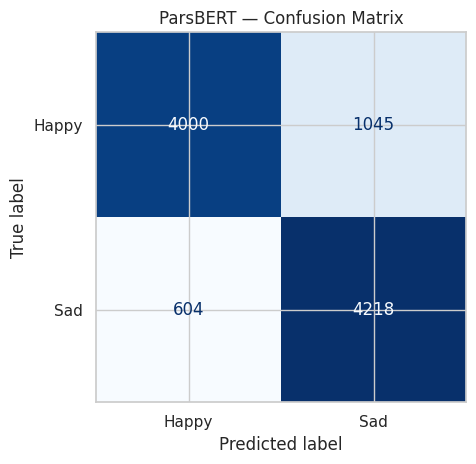

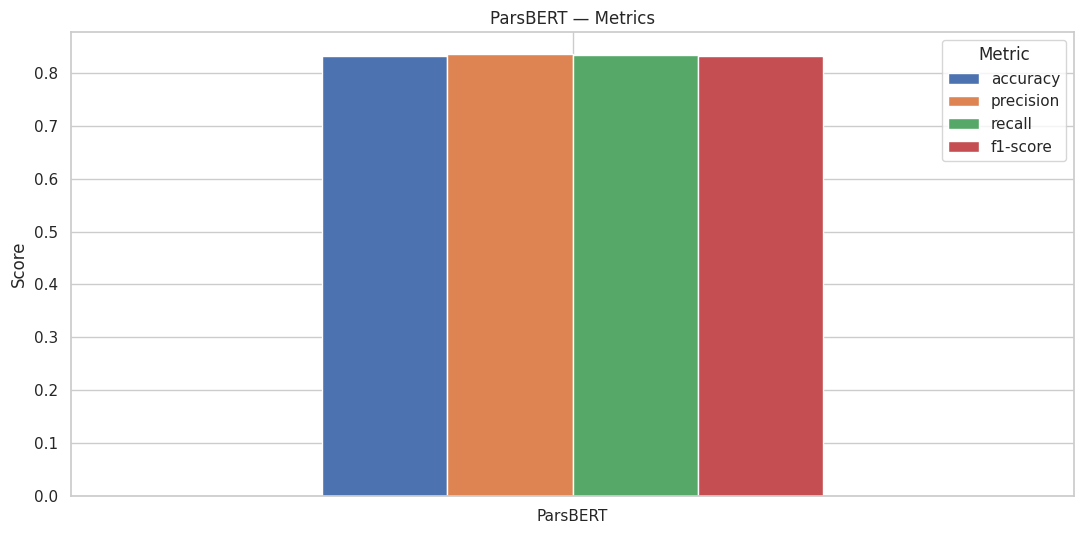

In [ ]:
show_confusion(bert_labels, bert_preds, title='ParsBERT — Confusion Matrix')
plt.tight_layout()
plt.show()

bert_report = classification_report(bert_labels, bert_preds, output_dict=True)
_ = compare_metrics({'ParsBERT': bert_report}, title='ParsBERT — Metrics')

Plots the ROC curve for the ParsBERT model.

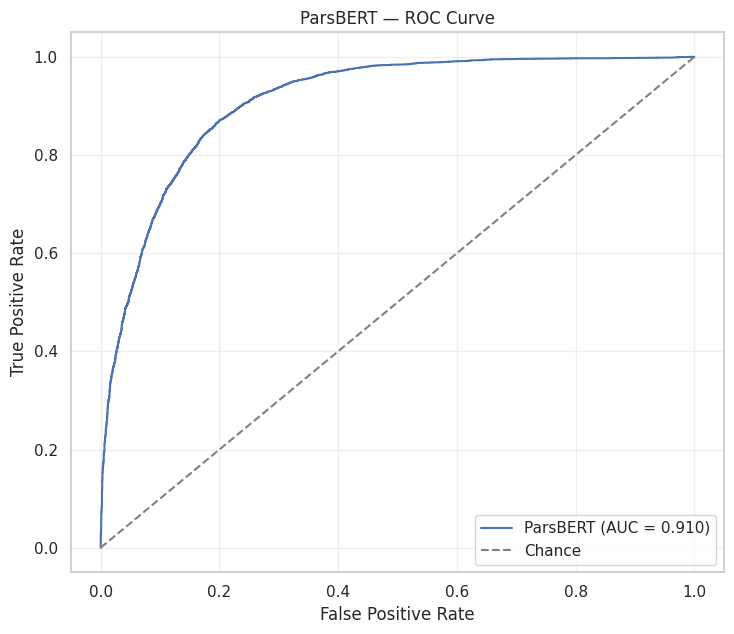

In [ ]:
overlay_roc({'ParsBERT': bert_scores}, bert_labels,
            title='ParsBERT — ROC Curve')

Plots ParsBERT's training/validation loss curve across epochs.

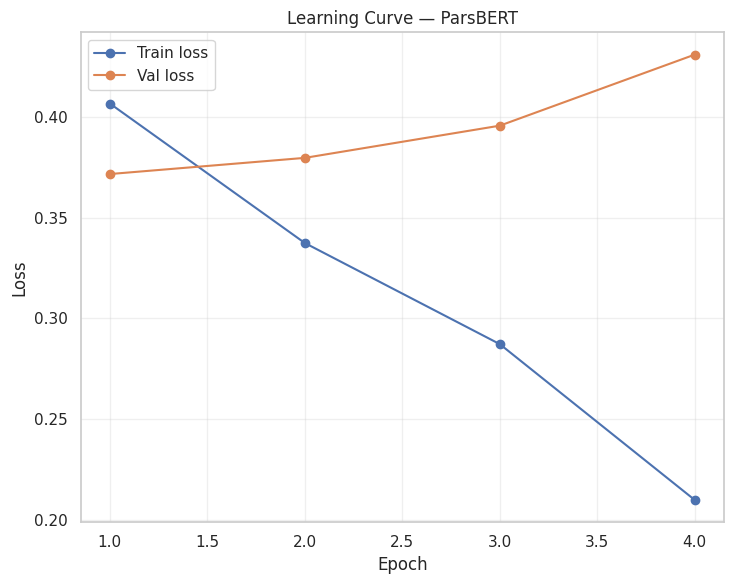

In [44]:
loss_curve(bert_history, title='ParsBERT')

Saves the fine-tuned model and its tokenizer to a local directory so they can be reloaded later without retraining.

In [ ]:
SAVE_DIR = 'parsbert_finetuned'
bert_net.save_pretrained(SAVE_DIR)
bert_tok.save_pretrained(SAVE_DIR)
print(f'saved to ./{SAVE_DIR}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved to ./parsbert_finetuned


## Wrap-up

All three approaches were evaluated on the same held-out test data using
identical diagnostics (classification report, confusion matrix, ROC curve,
learning curve), which makes the accuracy/cost trade-off between a
TF-IDF + classical model, a from-scratch sequence model, and a fine-tuned
transformer directly comparable rather than anecdotal.